# Parameter Scans 1D (v2)

1D loss and gradient sweeps over reconstruction parameters using the
`gradient_analysis` sweep library.  Uses **data mode** (ROOT files) and
`ParticleParams` with t0.

In [1]:
import sys
sys.path.append('../')

from tools.geometry import generate_detector
from tools.simulation import setup_event_simulator
from tools.detector_params import ParticleParams
from tools.generate import read_photon_data_from_photonsim
from tools.optimization.losses import counts_loss, origin_time_loss, cone_time_loss
from tools.gradient_analysis import (
    SweepParam, sweep_1d, plot_sweep_1d, find_zero_crossing, RECO_SWEEPS,
)
from tools.utils import spherical_to_cartesian

import jax
import jax.numpy as jnp
from jax import jit, value_and_grad

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from scipy.stats import linregress
import uproot

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

## Configuration

In [2]:
GEOM_CONFIG = '../config/SK_geom_config.json'
DATA_FILE = '../data/water/muon/muon_gun_1050_MeV_100_events_fixed_energy.root'
TEMPERATURE = 0.10
K = 9
Nphot = 300_000
C_MEDIUM = 0.299792 / 1.33  # speed of light in water (m/ns)

## Detector + Simulator Setup

In [3]:
PHYSICS_CONFIG = '../config/SK_physics_config.json'

detector = generate_detector(GEOM_CONFIG)
detector_points = jnp.array(detector.all_points)
NUM_DETECTORS = len(detector_points)
print(f'Number of sensors: {NUM_DETECTORS}')

# Data simulator: ROOT photons, no temperature smoothing, high K
# default_detector_params=True loads and expands qe_corrections automatically
data_simulator = setup_event_simulator(
    GEOM_CONFIG, Nphot, temperature=0.0, K=20,
    is_data=True, is_calibration=False,
    physics_config=PHYSICS_CONFIG,
    default_detector_params=True,
)

# Prediction simulator: SIREN-based differentiable simulation
prediction_simulator = setup_event_simulator(
    GEOM_CONFIG, Nphot, TEMPERATURE, max_sensors_per_cell=4,
    K=K, is_data=False,
    physics_config=PHYSICS_CONFIG,
    default_detector_params=True,
)

# Load ROOT file info
with uproot.open(DATA_FILE) as f:
    tree = f['OpticalPhotons']
    N_ENTRIES = tree.num_entries
print(f'ROOT file has {N_ENTRIES} entries')

Number of sensors: 10764
ROOT file has 100 entries


## Loss Functions

In [4]:
@jit
def combined_product_loss(particle_params, true_data, key):
    """Combined loss: sqrt(vertex_time * counts * cone_time).

    Takes a ParticleParams pytree (with t0) and returns a scalar loss.
    Loss functions handle hit masking internally via jnp.where weighting.
    """
    position = particle_params.position
    t0 = particle_params.t0

    hit_counts, hit_times = true_data

    # Simulated prediction
    simulated_data = prediction_simulator(particle_params, key)
    simulated_counts = simulated_data[0]
    simulated_time = simulated_data[1]

    # Individual components (all use full-length arrays; internal weighting
    # by charge zeros out non-hit sensors)
    vertex_loss = origin_time_loss(
        position, detector_points,
        hit_times, hit_counts, t0,
    )
    counts_loss_val = counts_loss(hit_counts, simulated_counts)
    time_loss = cone_time_loss(
        hit_counts, simulated_time, hit_times, t0, tau=0.12,
    )

    return jnp.sqrt(
        (vertex_loss + 1e-6) * (counts_loss_val + 1e-6) * (time_loss + 1e-6)
    )

print('Loss function defined')

Loss function defined


## Load Single Event and Build Sweep Closure

In [5]:
def load_event_photon_data(data_file, entry_idx):
    """Load and pad photon data from ROOT file for data_simulator."""
    photon_data = read_photon_data_from_photonsim(data_file, entry_idx)
    origins = photon_data['photon_origins']
    directions = photon_data['photon_directions']
    times = photon_data['photon_times']
    N = len(origins)

    pad_size = max(0, 1_000_000 - N)
    photon_data['photon_origins'] = jnp.pad(
        origins, ((0, pad_size), (0, 0)), mode='constant', constant_values=0)

    default_dir = jnp.array([0.0, 0.0, 1.0])
    if pad_size > 0:
        photon_data['photon_directions'] = jnp.concatenate(
            [directions, jnp.tile(default_dir, (pad_size, 1))], axis=0)
    else:
        photon_data['photon_directions'] = directions

    photon_data['photon_times'] = jnp.pad(
        times, (0, pad_size), mode='constant', constant_values=0)
    photon_data['N'] = N
    # Rotation/translation set later by set_photon_transform()
    photon_data['apply_rotation'] = jnp.array(False)
    photon_data['rotation_axis'] = jnp.array([1.0, 0.0, 0.0])
    photon_data['rotation_angle'] = jnp.array(0.0)
    return photon_data


def set_photon_transform(photon_data, particle_params):
    """Compute and set rotation/translation on photon_data from ParticleParams.

    ROOT photons are emitted along z-axis from the origin.  This function
    computes the rotation that aligns [0,0,1] with the track direction
    (from theta/phi) and translates photon origins to the track vertex.
    """
    original_dir = jnp.array([0.0, 0.0, 1.0])
    target_dir = particle_params.direction  # derived from theta, phi
    target_dir = target_dir / (jnp.linalg.norm(target_dir) + 1e-8)

    rotation_axis = jnp.cross(original_dir, target_dir)
    axis_norm = jnp.linalg.norm(rotation_axis)
    # When directions are (anti-)parallel, pick an arbitrary perpendicular axis
    rotation_axis = jnp.where(
        axis_norm < 1e-6,
        jnp.array([1.0, 0.0, 0.0]),
        rotation_axis / (axis_norm + 1e-8),
    )
    rotation_angle = jnp.arccos(jnp.clip(
        jnp.dot(original_dir, target_dir), -1.0, 1.0,
    ))

    photon_data['rotation_axis'] = rotation_axis
    photon_data['rotation_angle'] = rotation_angle
    photon_data['apply_rotation'] = jnp.array(True)

    photon_data['translation_vector'] = particle_params.position
    photon_data['apply_translation'] = jnp.array(True)
    return photon_data


def generate_random_track(key, detector, energy):
    """Generate a random track inside the detector volume.

    Parameters
    ----------
    key : JAX PRNGKey
    detector : Detector geometry
    energy : scalar energy (MeV) from the ROOT file
    """
    fraction = 0.6
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)

    r_vert = jax.random.uniform(k1, minval=0, maxval=detector.r * fraction)
    theta_pos = jax.random.uniform(k2, minval=0, maxval=2 * jnp.pi)
    z_vert = jax.random.uniform(k3, minval=-detector.H / 2 * fraction,
                                maxval=detector.H / 2 * fraction)
    position = jnp.array([
        r_vert * jnp.cos(theta_pos),
        r_vert * jnp.sin(theta_pos),
        z_vert,
    ])

    theta = jax.random.uniform(k4, minval=0.01, maxval=jnp.pi - 0.01)
    phi = jax.random.uniform(k5, minval=-jnp.pi, maxval=jnp.pi)

    return ParticleParams(
        energy=jnp.array(float(energy)),
        position=position,
        theta=theta,
        phi=phi,
        t0=jnp.array(0.0),
    )

In [6]:
# --- Single event demo ---
entry_idx = 2
photon_data = load_event_photon_data(DATA_FILE, entry_idx)

key = jax.random.PRNGKey(44)
true_params = generate_random_track(key, detector, photon_data['energy'])

# Apply rotation/translation so ROOT photons match the random track
photon_data = set_photon_transform(photon_data, true_params)

# Generate reference data
key_data = jax.random.PRNGKey(100)
true_data = jax.lax.stop_gradient(
    data_simulator(true_params, key_data, photon_data)
)
n_hit = int(jnp.sum(true_data[0] > -1))
print(f'Hit sensors: {n_hit}')
print(f'True params: E={float(true_params.energy):.1f} MeV, '
      f'pos=[{float(true_params.position[0]):.2f}, '
      f'{float(true_params.position[1]):.2f}, '
      f'{float(true_params.position[2]):.2f}], '
      f'theta={float(true_params.theta):.3f}, '
      f'phi={float(true_params.phi):.3f}, '
      f't0={float(true_params.t0):.1f}')

# Build loss_and_grad closure for sweep library
key_pred = jax.random.PRNGKey(42)

@jit
def loss_and_grad_fn(pp):
    return value_and_grad(lambda p: combined_product_loss(p, true_data, key_pred))(pp)

# Warmup JIT
_ = loss_and_grad_fn(true_params)
print('JIT warmup done')

Hit sensors: 10764
True params: E=1050.0 MeV, pos=[-6.24, -3.32, -0.41], theta=0.332, phi=-1.318, t0=0.0
JIT warmup done


## 1D Parameter Sweeps

phi: 100%|██████████| 41/41 [00:03<00:00, 11.79it/s]


(<Figure size 2800x700 with 14 Axes>,
 array([[<Axes: xlabel='X (m)', ylabel='Loss'>,
         <Axes: xlabel='Y (m)', ylabel='Loss'>,
         <Axes: xlabel='Z (m)', ylabel='Loss'>,
         <Axes: xlabel='t0 (ns)', ylabel='Loss'>,
         <Axes: xlabel='Energy (MeV)', ylabel='Loss'>,
         <Axes: xlabel='$\\theta$ (rad)', ylabel='Loss'>,
         <Axes: xlabel='$\\phi$ (rad)', ylabel='Loss'>],
        [<Axes: xlabel='X (m)', ylabel='Gradient'>,
         <Axes: xlabel='Y (m)', ylabel='Gradient'>,
         <Axes: xlabel='Z (m)', ylabel='Gradient'>,
         <Axes: xlabel='t0 (ns)', ylabel='Gradient'>,
         <Axes: xlabel='Energy (MeV)', ylabel='Gradient'>,
         <Axes: xlabel='$\\theta$ (rad)', ylabel='Gradient'>,
         <Axes: xlabel='$\\phi$ (rad)', ylabel='Gradient'>]], dtype=object))

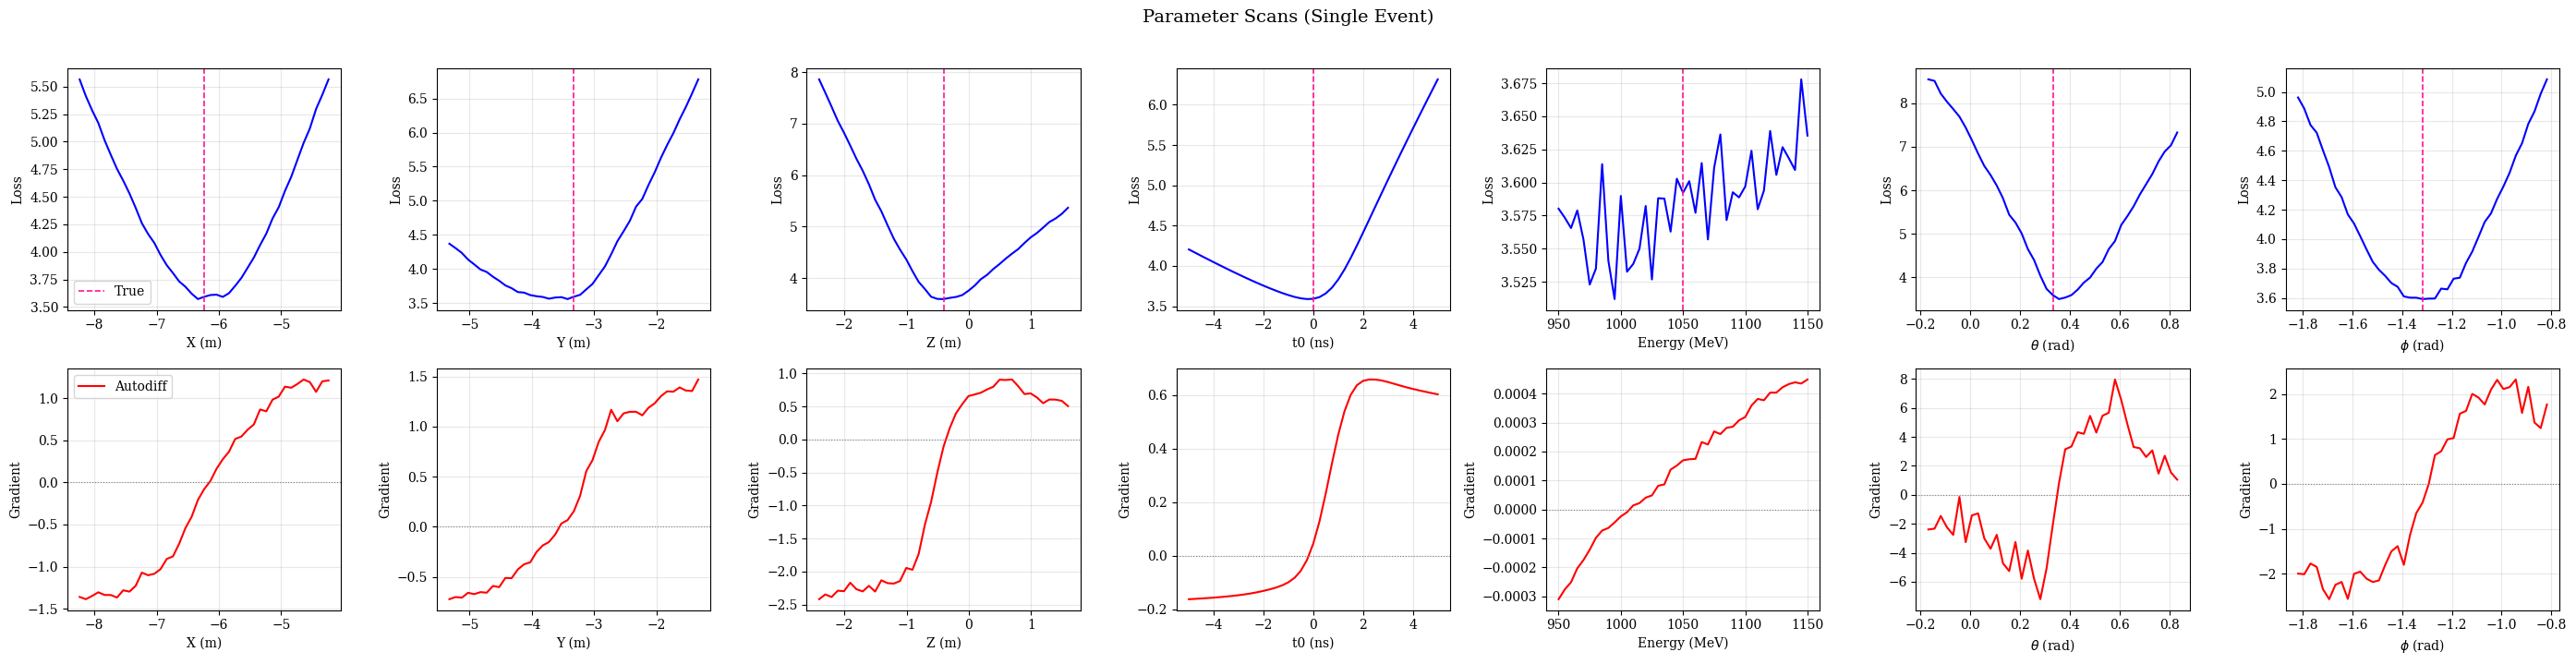

In [7]:
results_1d = sweep_1d(loss_and_grad_fn, true_params, RECO_SWEEPS)
Path('figures').mkdir(exist_ok=True)
plot_sweep_1d(results_1d, title='Parameter Scans (Single Event)',
             save_path='figures/parameter_scans_1D.png', show_numerical=False)

## Summary Table

In [8]:
print('=' * 80)
print('PARAMETER SCAN SUMMARY')
print('=' * 80)
print(f"{'Parameter':<14} {'True':<12} {'Min-Loss':<12} {'Delta':<12} {'Zero-Cross?':<12}")
print('-' * 80)

for name, res in results_1d.items():
    center = res.param.center
    min_idx = np.argmin(res.losses)
    min_val = res.values[min_idx]
    delta = min_val - center
    zc = find_zero_crossing(res.values, res.gradients)
    has_zc = 'Yes' if not np.isnan(zc) else 'No'
    print(f'{name:<14} {center:<12.4f} {min_val:<12.4f} {delta:<12.4f} {has_zc:<12}')

print('=' * 80)

PARAMETER SCAN SUMMARY
Parameter      True         Min-Loss     Delta        Zero-Cross? 
--------------------------------------------------------------------------------
X              -6.2369      -6.3369      -0.1000      Yes         
Y              -3.3244      -3.4244      -0.1000      Yes         
Z              -0.4059      -0.4059      0.0000       Yes         
t0             0.0000       -0.2500      -0.2500      Yes         
Energy         1050.0000    995.0000     -55.0000     Yes         
theta          0.3320       0.3570       0.0250       Yes         
phi            -1.3180      -1.3180      0.0000       Yes         


# Multi-Event Analysis

Run 1D sweeps across 25 events to characterize gradient zero-crossing
resolution for position X and t0 parameters.

In [9]:
N_EVENTS = 25

In [10]:
all_event_results = []

main_key = jax.random.PRNGKey(42)
event_keys = jax.random.split(main_key, N_EVENTS)

# Select which sweeps to run for multi-event (X and t0)
multi_sweeps = [
    SweepParam('Position X', 'position', half_width=0.5, index=0, unit='m'),
    SweepParam('t0',         't0',       half_width=5.0, unit='ns'),
]

key_pred = jax.random.PRNGKey(42)

@jit
def _loss_and_grad(pp, td):
    return value_and_grad(
        lambda p: combined_product_loss(p, td, key_pred)
    )(pp)

print(f'Running {N_EVENTS} events x {len(multi_sweeps)} sweeps...')

for event_idx in tqdm(range(N_EVENTS), desc='Events'):
    entry_idx = event_idx % N_ENTRIES
    photon_data = load_event_photon_data(DATA_FILE, entry_idx)

    evt_key = event_keys[event_idx]
    true_pp = generate_random_track(evt_key, detector, photon_data['energy'])

    # Apply rotation/translation so ROOT photons match this track
    photon_data = set_photon_transform(photon_data, true_pp)

    key_data = jax.random.PRNGKey(1000 + event_idx)
    td = jax.lax.stop_gradient(
        data_simulator(true_pp, key_data, photon_data)
    )
    n_hit = int(jnp.sum(td[0] > -1))

    res = sweep_1d(lambda pp: _loss_and_grad(pp, td), true_pp, multi_sweeps)

    all_event_results.append({
        'true_params': true_pp,
        'n_hit': n_hit,
        'sweep_results': res,
    })

print(f'Completed {len(all_event_results)} events')

Running 25 events x 2 sweeps...


Position X: 100%|██████████| 41/41 [00:31<00:00,  1.32it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.26it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.36it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.35it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.32it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.14it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.48it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.05it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.43it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.36it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.49it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.28it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.14it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.33it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.45it/s]

Position X: 100%|██████████| 41/41 [00:03<00:00, 11.08it/s]

Position X: 100%|███████

Completed 25 events


In [11]:
# Extract zero-crossings for each parameter
delta_results = {}  # param_name -> list of deltas

for sp in multi_sweeps:
    deltas = []
    for evt in all_event_results:
        res = evt['sweep_results'][sp.name]
        center = res.param.center
        zc = find_zero_crossing(res.values, res.gradients)
        deltas.append(zc - center if not np.isnan(zc) else np.nan)
    delta_results[sp.name] = np.array(deltas)

for name, deltas in delta_results.items():
    valid = deltas[~np.isnan(deltas)]
    print(f'{name}: {len(valid)}/{len(deltas)} zero-crossings, '
          f'mean={np.mean(valid):.4f}, sigma={np.std(valid):.4f}')

Position X: 25/25 zero-crossings, mean=-0.0109, sigma=0.0739
t0: 25/25 zero-crossings, mean=-0.2290, sigma=0.0660


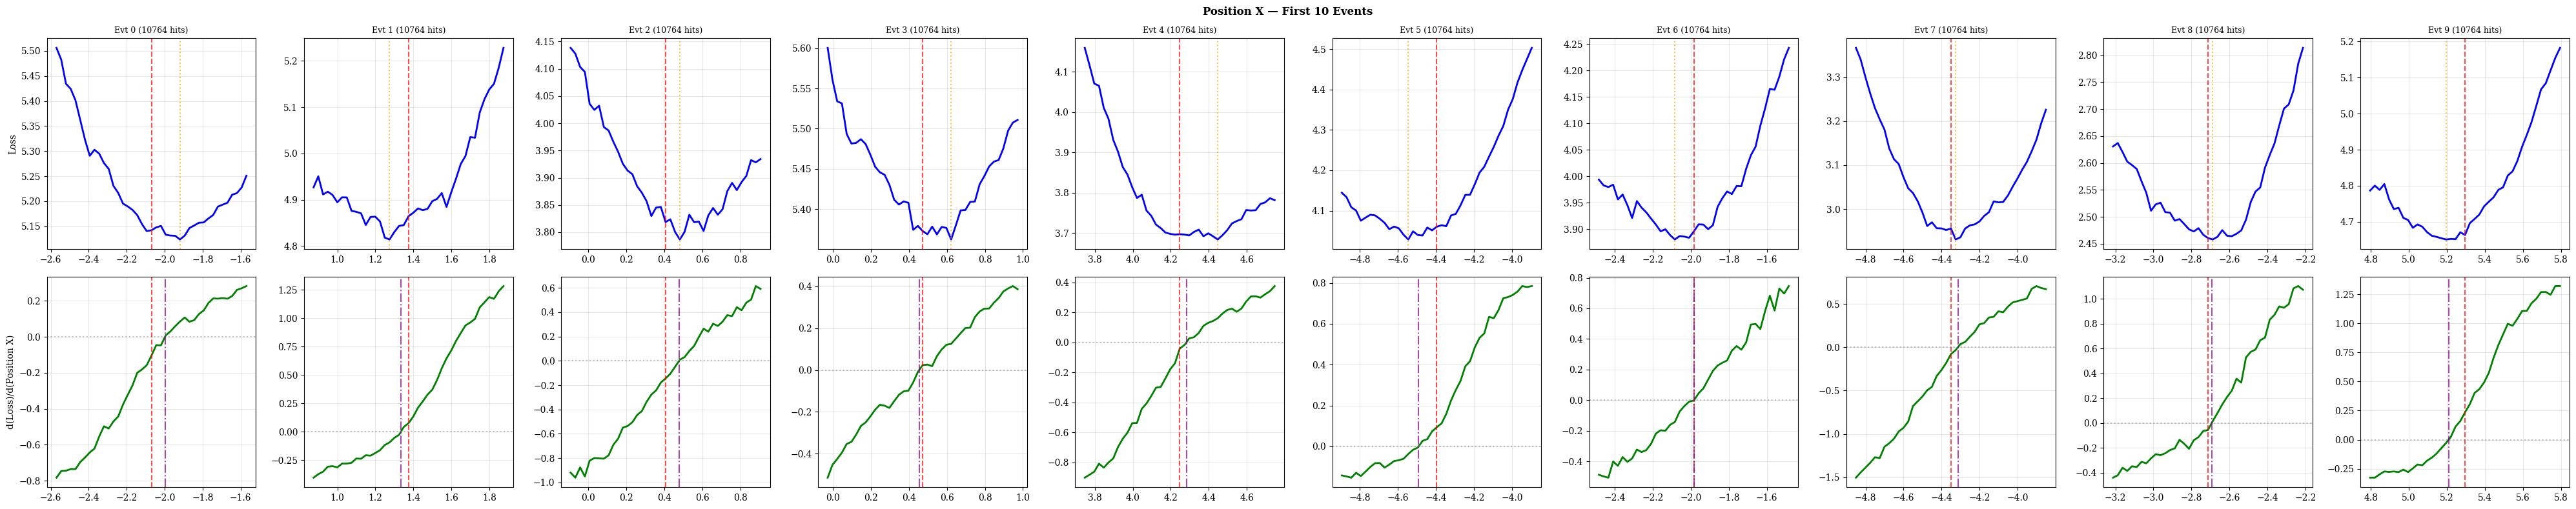

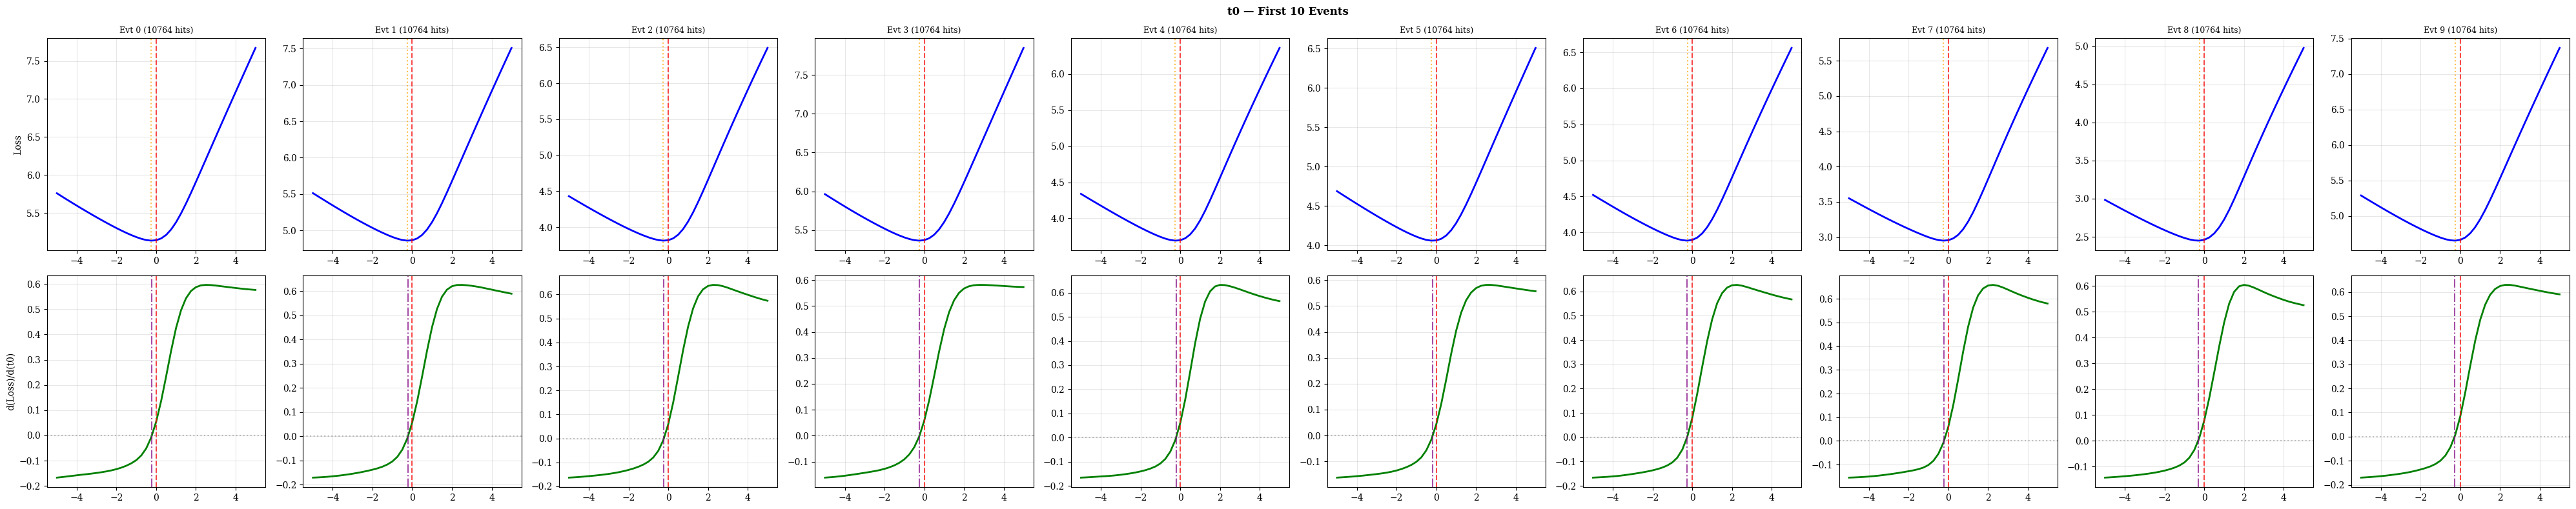

In [12]:
n_plot = min(10, N_EVENTS)

for sp in multi_sweeps:
    fig, axes = plt.subplots(2, n_plot, figsize=(4 * n_plot, 8), squeeze=False)

    for i in range(n_plot):
        evt = all_event_results[i]
        res = evt['sweep_results'][sp.name]
        center = res.param.center
        delta = delta_results[sp.name][i]

        # Loss
        axes[0, i].plot(res.values, res.losses, 'b-', linewidth=2)
        axes[0, i].axvline(center, color='red', linestyle='--', alpha=0.7, label='True')
        min_idx = np.argmin(res.losses)
        axes[0, i].axvline(res.values[min_idx], color='orange', linestyle=':', alpha=0.7, label='Min')
        axes[0, i].set_title(f'Evt {i} ({evt["n_hit"]} hits)', fontsize=9)
        if i == 0:
            axes[0, i].set_ylabel('Loss')
        axes[0, i].grid(True, alpha=0.3)

        # Gradient
        axes[1, i].plot(res.values, res.gradients, 'g-', linewidth=2)
        axes[1, i].axvline(center, color='red', linestyle='--', alpha=0.7)
        axes[1, i].axhline(0, color='gray', linestyle=':', alpha=0.5)
        if not np.isnan(delta):
            axes[1, i].axvline(center + delta, color='purple', linestyle='-.',
                               alpha=0.7, label='Zero')
        if i == 0:
            axes[1, i].set_ylabel(f'd(Loss)/d({sp.name})')
        axes[1, i].grid(True, alpha=0.3)

    fig.suptitle(f'{sp.name} — First {n_plot} Events', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/multi_event_{sp.name.replace(" ", "_")}.png',
                dpi=200, bbox_inches='tight')
    plt.show()

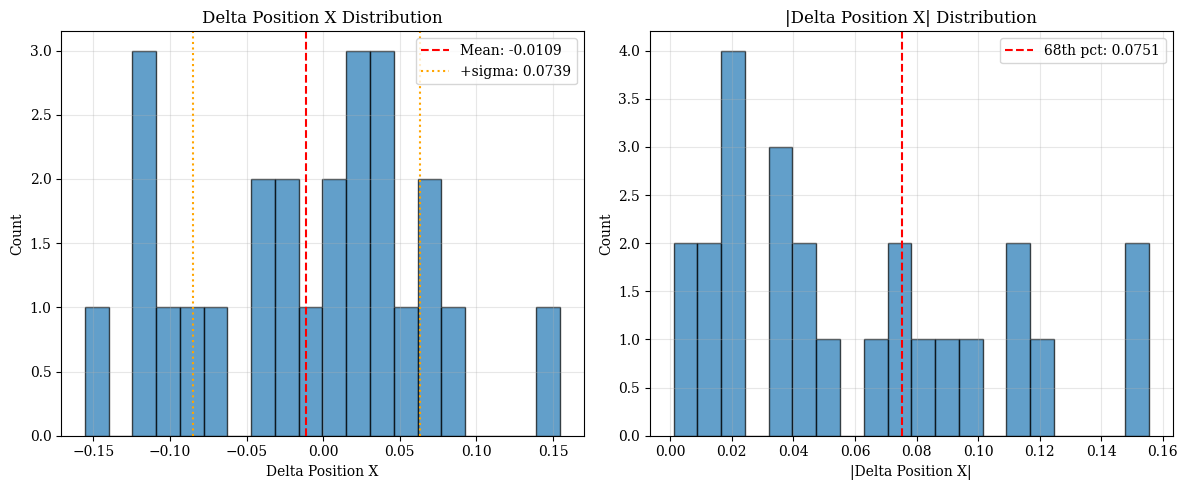

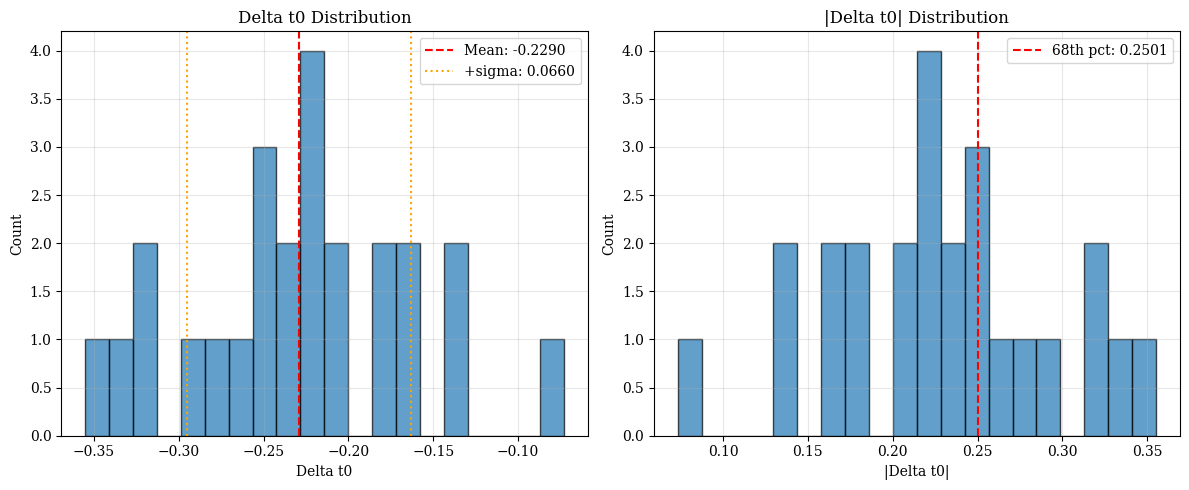

In [13]:
for sp_name, deltas in delta_results.items():
    valid = deltas[~np.isnan(deltas)]
    mean_d = np.mean(valid)
    sigma_d = np.std(valid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.hist(valid, bins=20, alpha=0.7, edgecolor='black')
    ax1.axvline(mean_d, color='red', linestyle='--', label=f'Mean: {mean_d:.4f}')
    ax1.axvline(mean_d + sigma_d, color='orange', linestyle=':',
               label=f'+sigma: {sigma_d:.4f}')
    ax1.axvline(mean_d - sigma_d, color='orange', linestyle=':')
    ax1.set_xlabel(f'Delta {sp_name}')
    ax1.set_ylabel('Count')
    ax1.set_title(f'Delta {sp_name} Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    abs_d = np.abs(valid)
    p68 = np.percentile(abs_d, 68) if len(abs_d) > 0 else 0
    ax2.hist(abs_d, bins=20, alpha=0.7, edgecolor='black')
    ax2.axvline(p68, color='red', linestyle='--',
               label=f'68th pct: {p68:.4f}')
    ax2.set_xlabel(f'|Delta {sp_name}|')
    ax2.set_ylabel('Count')
    ax2.set_title(f'|Delta {sp_name}| Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'figures/histogram_{sp_name.replace(" ", "_")}.png',
                dpi=200, bbox_inches='tight')
    plt.show()

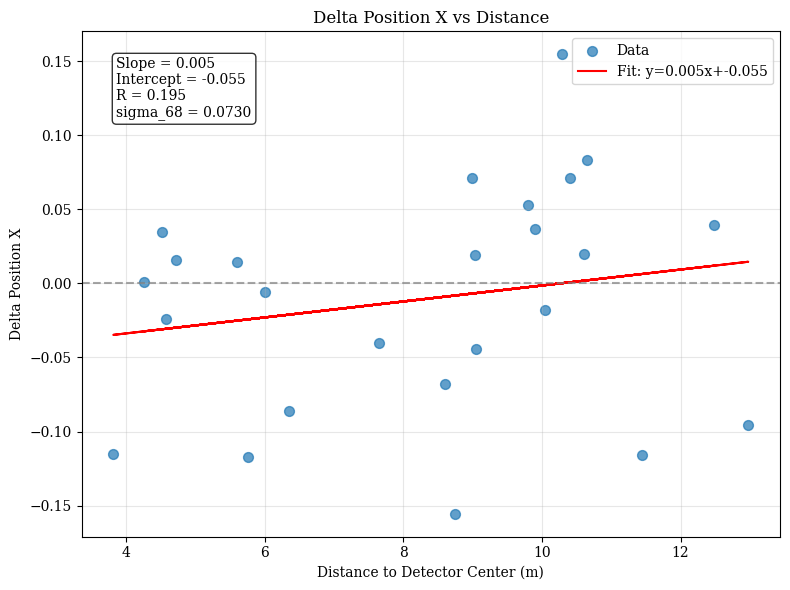

Position X: slope=0.0054, R=0.1950, sigma_68=0.0730


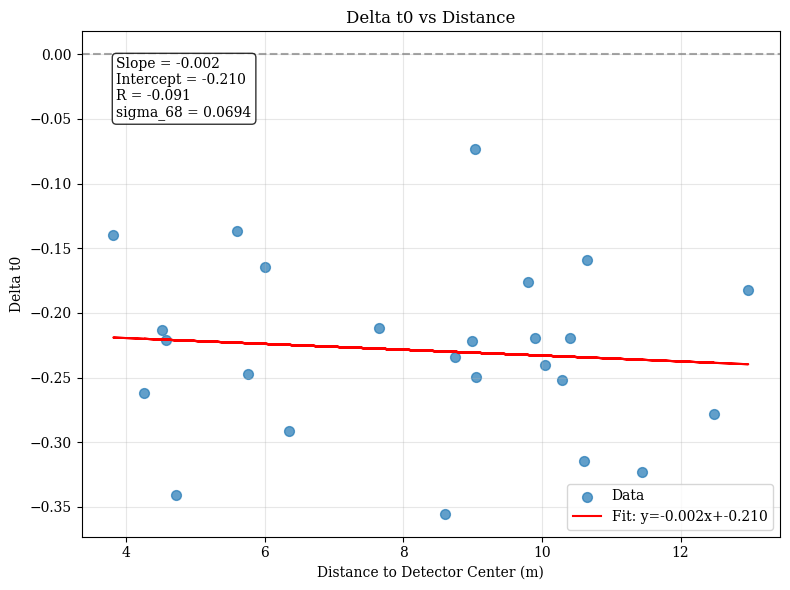

t0: slope=-0.0023, R=-0.0914, sigma_68=0.0694


In [14]:
# Correlation: delta vs distance to detector center
for sp_name, deltas in delta_results.items():
    distances = np.array([
        float(jnp.linalg.norm(evt['true_params'].position))
        for evt in all_event_results
    ])
    valid_mask = ~np.isnan(deltas)
    valid_d = deltas[valid_mask]
    valid_dist = distances[valid_mask]

    if len(valid_d) < 3:
        print(f'{sp_name}: too few valid points for regression')
        continue

    slope, intercept, r_val, _, _ = linregress(valid_dist, valid_d)
    fit_line = slope * valid_dist + intercept
    residuals = np.abs(slope * valid_dist - valid_d + intercept) / np.sqrt(slope**2 + 1)
    sigma68 = np.percentile(residuals, 68)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(valid_dist, valid_d, alpha=0.7, s=50, label='Data')
    ax.plot(valid_dist, fit_line, color='red',
            label=f'Fit: y={slope:.3f}x+{intercept:.3f}')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
    ax.set_xlabel('Distance to Detector Center (m)')
    ax.set_ylabel(f'Delta {sp_name}')
    ax.set_title(f'Delta {sp_name} vs Distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.95,
            f'Slope = {slope:.3f}\nIntercept = {intercept:.3f}\n'
            f'R = {r_val:.3f}\nsigma_68 = {sigma68:.4f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'figures/correlation_{sp_name.replace(" ", "_")}.png',
                dpi=200, bbox_inches='tight')
    plt.show()

    print(f'{sp_name}: slope={slope:.4f}, R={r_val:.4f}, sigma_68={sigma68:.4f}')